# Road Sign Recognition - Data Exploration

This notebook explores the dataset for road sign recognition and provides visualizations to understand the data distribution.

## Important Note

This notebook provides two methods for exploring the GTSRB (German Traffic Sign Recognition Benchmark) dataset:

1. **Standard approach**: Uses basic data preparation functions (first part of the notebook)
2. **Alternative approach**: Uses the specialized `GTSRBDataset` class (later in the notebook)

If you encounter any issues with the standard approach, scroll down to the "ALTERNATIVE APPROACH" section which uses a more robust implementation specifically designed for the GTSRB dataset.

In [1]:
# Import necessary libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import importlib

# Add the src directory to the path to import our modules
sys.path.append('../src')

# Import and explicitly reload the module to ensure we get the latest version
import data_preparation
importlib.reload(data_preparation)
from data_preparation import load_data, preprocess_data, visualize_all_classes, data_distribution

## Load the Dataset

First, we'll load the dataset. 

In [2]:
# Set the data directory path to the raw folder
data_dir = '../data/raw'

# Use the Train.csv file for loading data
csv_file = '../data/raw/Train.csv'

# Limit samples for exploration to prevent memory issues
sample_limit = 39210  # Reduced sample limit to avoid memory issues

# Load the data
try:
    # Check if the CSV file exists
    if not os.path.exists(csv_file):
        print(f"CSV file not found at {csv_file}, looking for alternatives...")
        alternative_paths = [
            'data/raw/Train.csv',
            '../Train.csv',
            'Train.csv'
        ]
        for path in alternative_paths:
            if os.path.exists(path):
                csv_file = path
                print(f"Found alternative CSV file at {csv_file}")
                break
    
    if os.path.exists(csv_file):
        # Load data with limit - read first sample_limit rows from the CSV
        print(f"Loading data from {csv_file} with limit of {sample_limit} samples")
        df = pd.read_csv(csv_file, nrows=sample_limit)
        
        # Load images manually instead of using load_data function
        # to handle varying image sizes
        images = []
        labels = []
        
        for idx, row in df.iterrows():
            if idx % 10 == 0:
                print(f"Processing image {idx}/{len(df)}")
                
            img_path = os.path.join(data_dir, row['Path'])
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    # Resize immediately to avoid inhomogeneous array issues
                    img = cv2.resize(img, (32, 32))
                    images.append(img)
                    labels.append(row['ClassId'])
                else:
                    print(f"Warning: Could not load image at {img_path}")
            else:
                print(f"Warning: Image file does not exist at {img_path}")
        
        # Convert to numpy arrays
        images = np.array(images)
        labels = np.array(labels)
        
        print(f"Loaded {len(images)} images with {len(np.unique(labels))} classes")
        print(f"Images shape: {images.shape}")
        
    else:
        print(f"Could not find Train.csv in any expected location")
        images = np.array([])
        labels = np.array([])
        
except Exception as e:
    print(f"Error loading data: {e}")
    # Initialize empty arrays if loading failed
    images = np.array([])
    labels = np.array([])

CSV file not found at ../data/raw/Train.csv, looking for alternatives...
Could not find Train.csv in any expected location


## Data Distribution

Let's check the distribution of classes in the dataset to see if it's balanced.

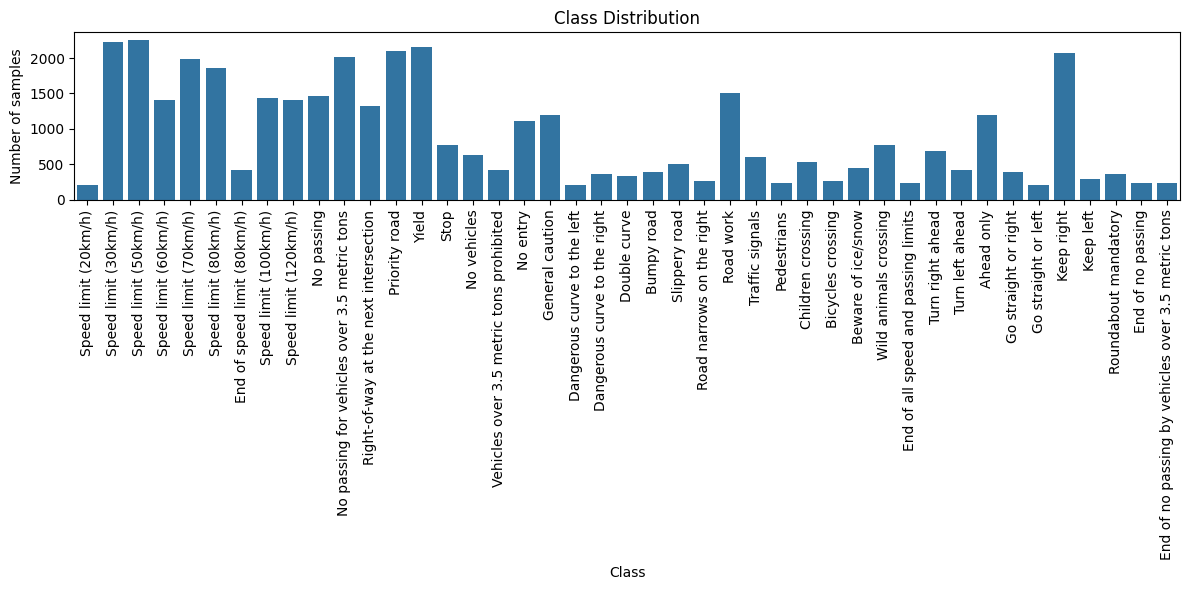

In [29]:
# Plot the distribution of classes
try:
    if len(labels) > 0:
        # Try to load class names if not already loaded
        if 'class_names' not in locals() or class_names is None:
            import json
            try:
                with open('../src/gtsrb_class_map.json', 'r') as f:
                    class_names = json.load(f)
                    # Convert string keys to integers
                    class_names = {int(k): v for k, v in class_names.items()}
            except Exception:
                class_names = None
                
        # Plot distribution with class names if available
        data_distribution(labels, class_names=class_names)
    else:
        print("No data available to plot distribution")
except Exception as e:
    print(f"Error plotting distribution: {e}")

## Visualize Sample Images

Let's visualize some sample images from each class to understand the dataset.

Found class map at ../src/gtsrb_class_map.json
Loaded 43 class names
Number of unique classes: 43
Visualizing 43 classes with 1 sample(s) per class


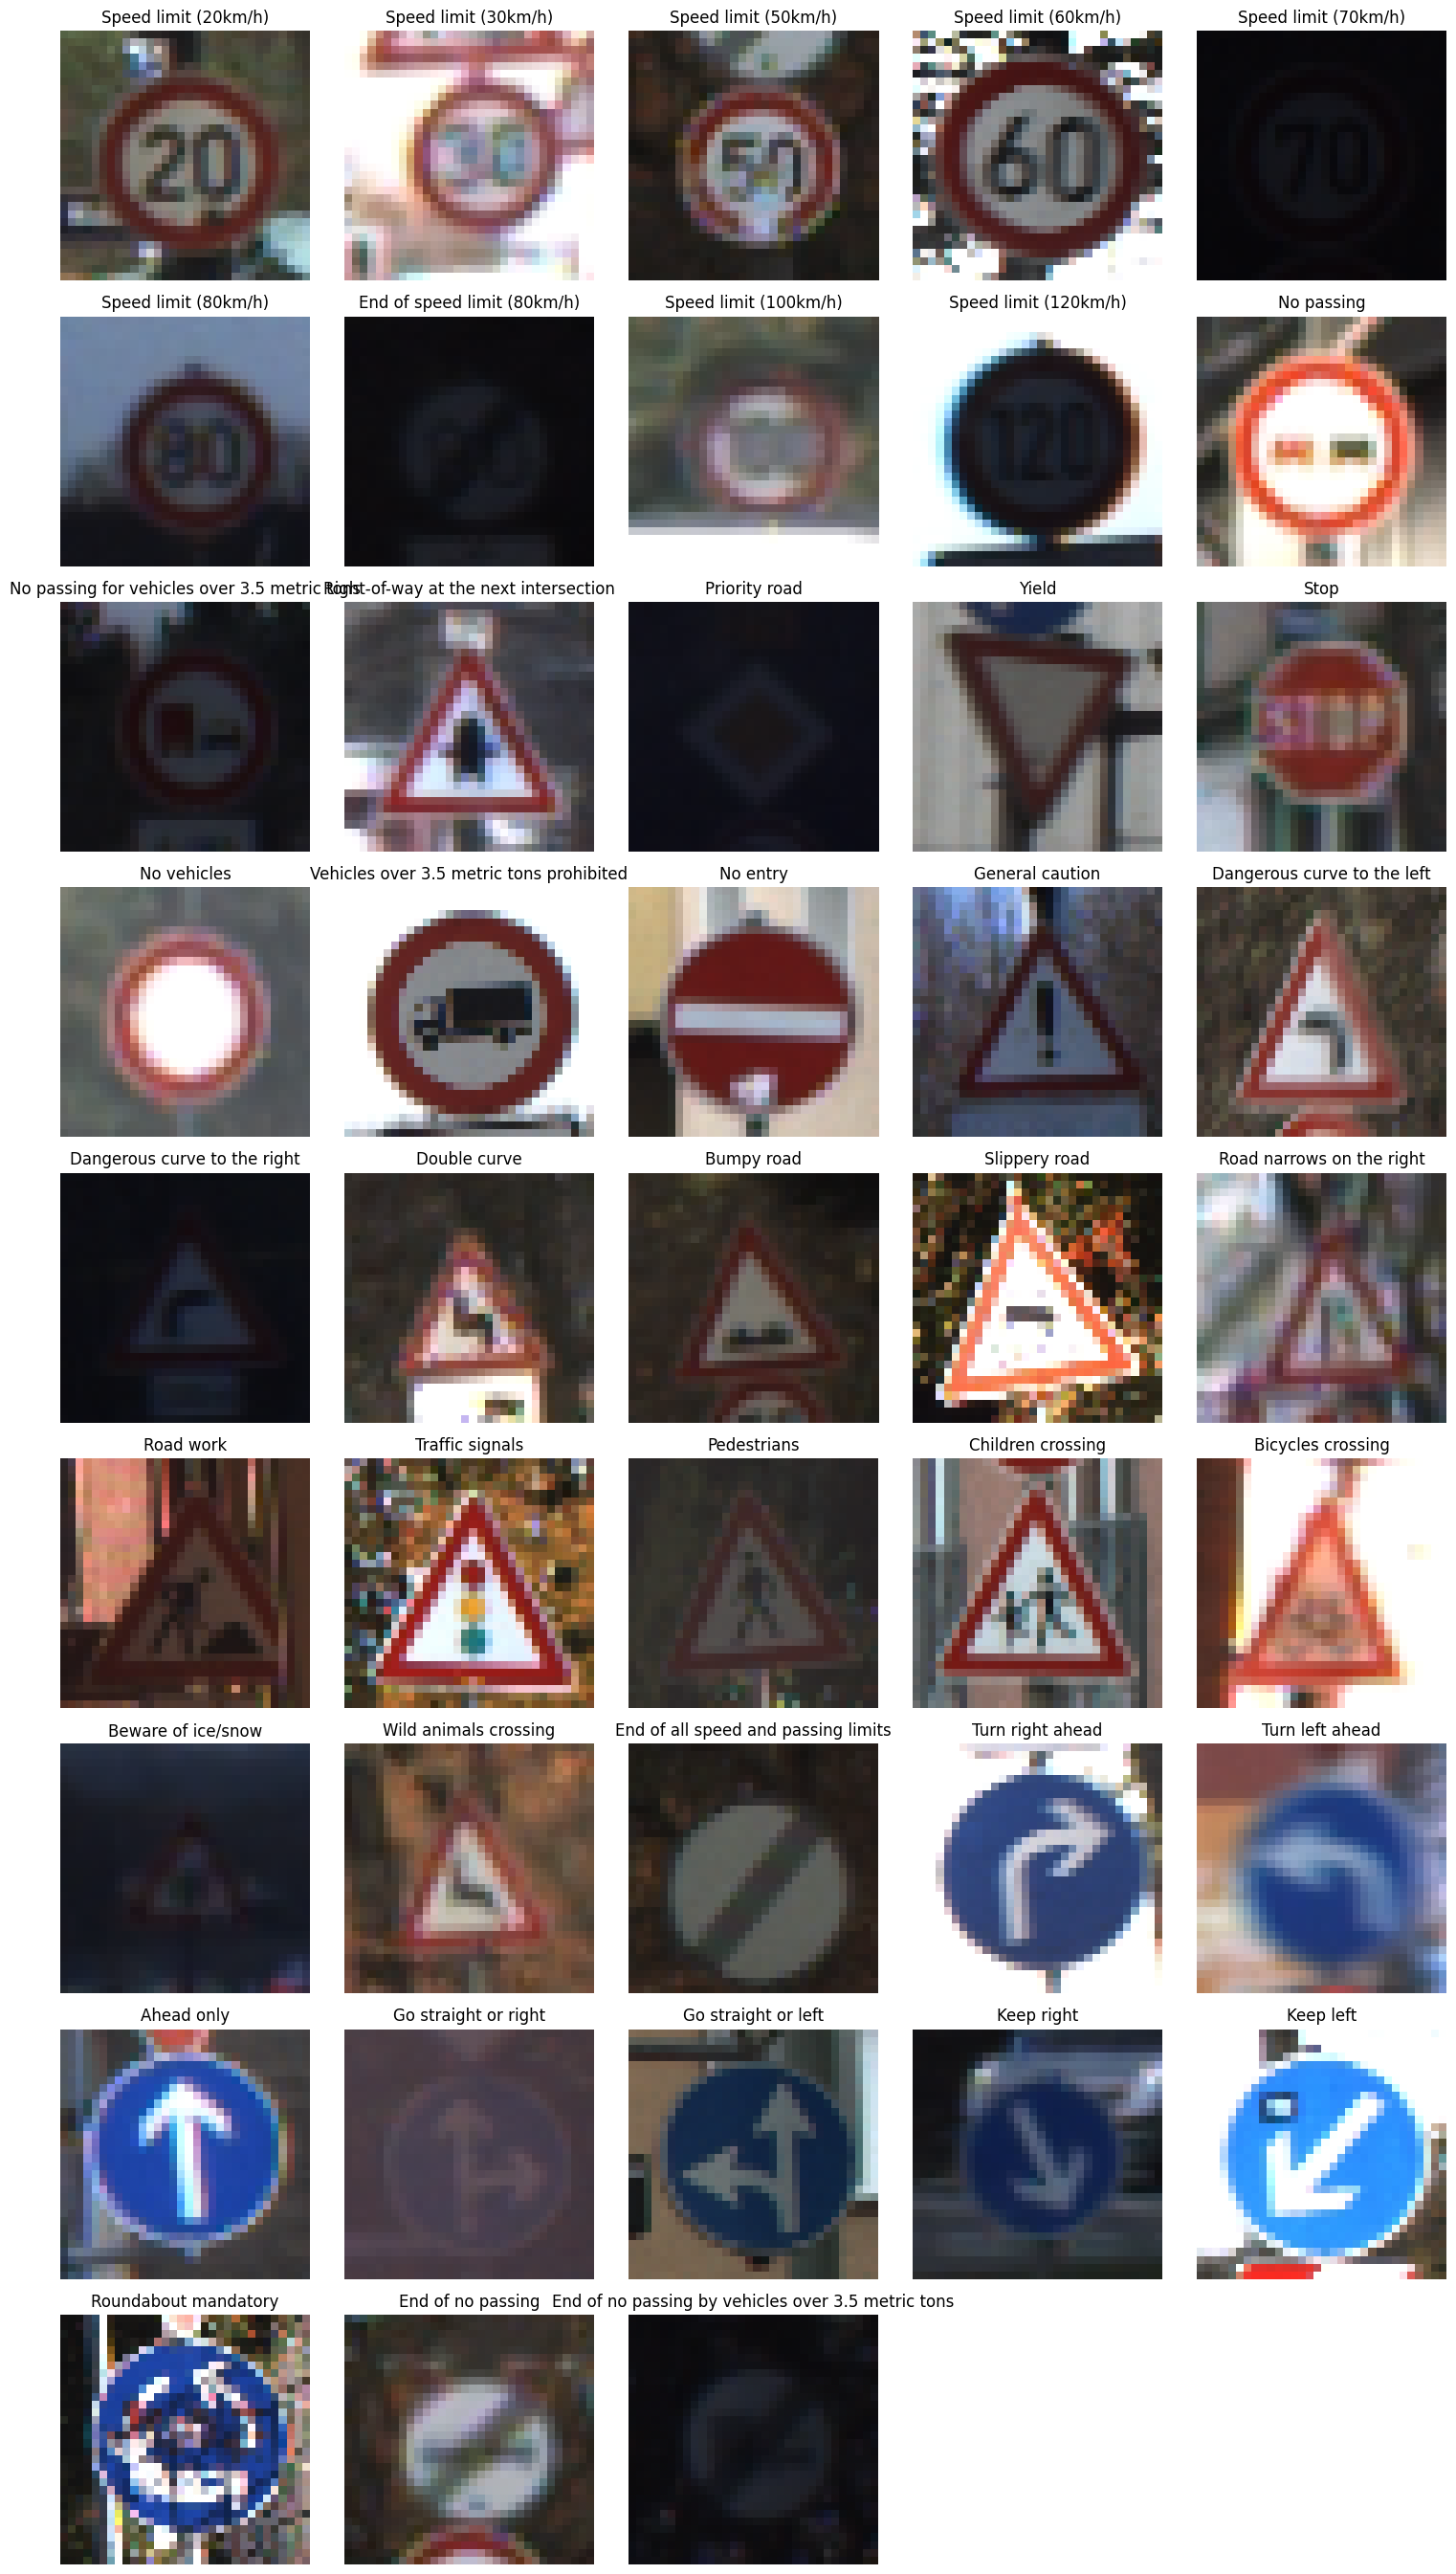

In [48]:
# Visualize sample images
try:
    # Load class names from the class map JSON file
    import json
    import os
    
    class_names = None
    # Try multiple possible locations for the class map
    class_map_paths = [
        '../src/gtsrb_class_map.json',
        'src/gtsrb_class_map.json',
        '../gtsrb_class_map.json',
        'gtsrb_class_map.json'
    ]
    
    for path in class_map_paths:
        try:
            if os.path.exists(path):
                print(f"Found class map at {path}")
                with open(path, 'r') as f:
                    class_names = json.load(f)
                    # Convert string keys to integers
                    class_names = {int(k): v for k, v in class_names.items()}
                print(f"Loaded {len(class_names)} class names")
                break
        except Exception as e:
            print(f"Error loading class map from {path}: {e}")
            
    if class_names is None:
        print("Could not load class map from any location, using generic class names")
    
    # Visualize all classes with the function that's defined in data_preparation.py
    print("Number of unique classes:", len(np.unique(labels)))
    visualize_all_classes(images, labels, class_names=class_names, samples_per_class=1)

except Exception as e:
    print(f"Error visualizing data: {e}")
    import traceback
    traceback.print_exc()  # Print the full traceback for debugging

## Image Preprocessing

Now let's preprocess the images to prepare them for training.

Images are already resized to 32x32
Processed images shape: (39209, 32, 32, 3)
Value range: [0.0, 1.0]
Processed images shape: (39209, 32, 32, 3)
Value range: [0.0, 1.0]


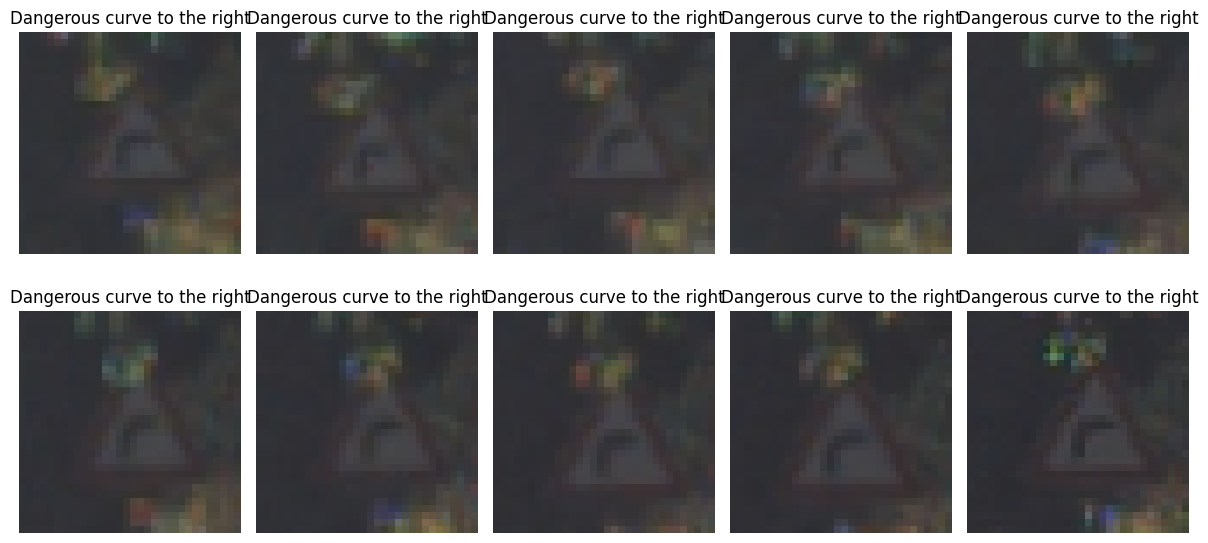

In [49]:
# Preprocess images
try:
    if len(images) > 0:
        # Check if images are already resized
        if images.shape[1:3] == (32, 32):
            print("Images are already resized to 32x32")
            processed_images = images / 255.0  # Just normalize
        else:
            # Resize images to 32x32 and normalize
            processed_images = preprocess_data(images, target_size=(32, 32))
            
        print(f"Processed images shape: {processed_images.shape}")
        print(f"Value range: [{processed_images.min()}, {processed_images.max()}]")
        
        # Show some processed images
        plt.figure(figsize=(12, 6))
        for i in range(min(10, len(processed_images))):
            plt.subplot(2, 5, i+1)
            plt.imshow(processed_images[i])
            # Use class names if available
            if class_names and labels[i] in class_names:
                plt.title(f"{class_names[labels[i]]}")
            else:
                plt.title(f"Class {labels[i]}")
            plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("No images available to preprocess")
except Exception as e:
    print(f"Error preprocessing images: {e}")

## Image Augmentation Examples

Let's see how our augmentation functions work on sample images.

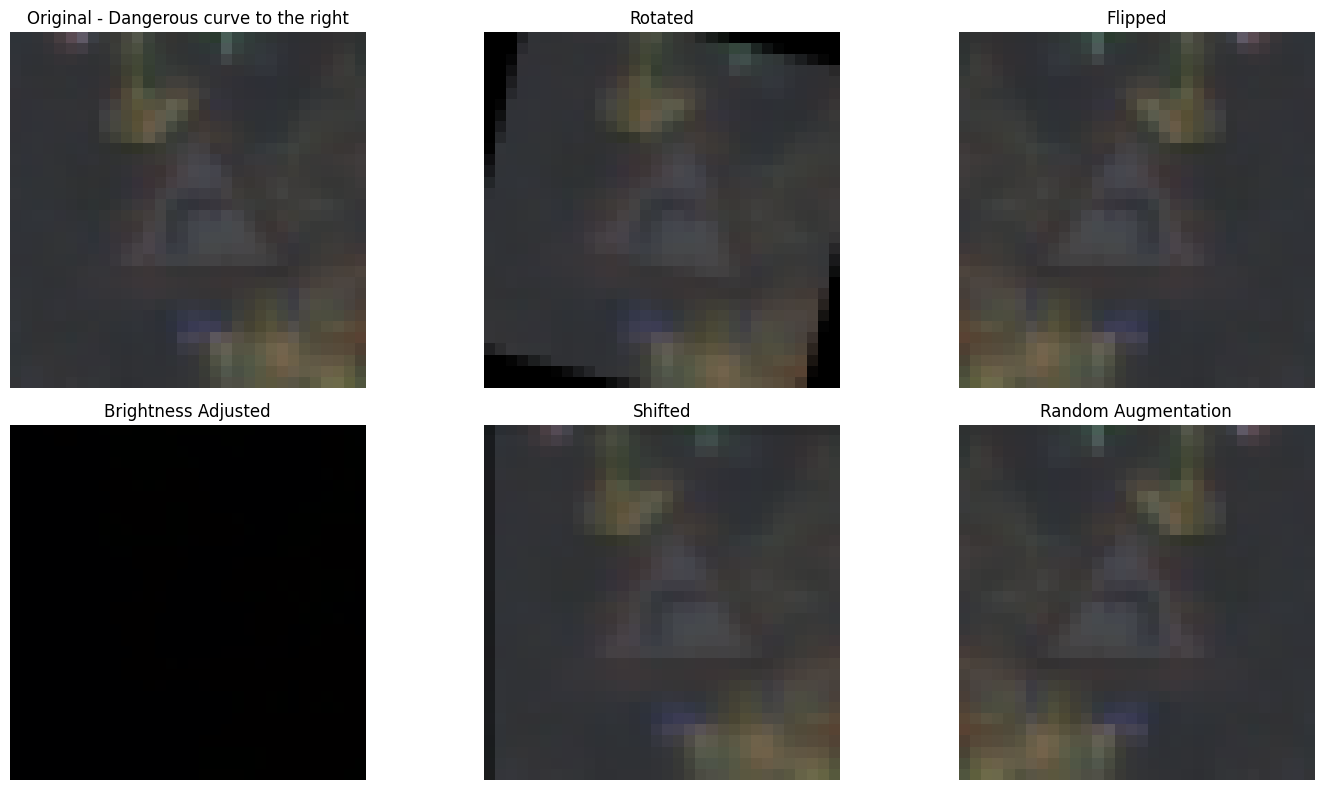

In [53]:
# Import the augmentation function - Make sure the path is correct
try:
    # First try the direct import (when running from notebook)
    from utils import apply_augmentation
except ImportError:
    try:
        # Then try the relative import (when src is added to path)
        from src.utils import apply_augmentation
    except ImportError:
        print("Could not import apply_augmentation, please check your import paths")
        
# Apply various augmentations to a sample image
try:
    sample_idx = 0  # Choose a sample image
    if len(processed_images) > 0:
        sample_img = processed_images[sample_idx]
        sample_label = labels[sample_idx]
        
        # Convert back to uint8 format for OpenCV functions
        # First ensure values are in 0-1 range, then scale to 0-255 and convert to uint8
        sample_img_uint8 = (np.clip(sample_img, 0, 1) * 255).astype(np.uint8)
        
        plt.figure(figsize=(15, 8))
        
        # Original image
        plt.subplot(2, 3, 1)
        plt.imshow(sample_img)  # Display original normalized image
        label_name = class_names.get(sample_label, f"Class {sample_label}") if class_names else f"Class {sample_label}"
        plt.title(f"Original - {label_name}")
        plt.axis('off')
        
        # Rotated image
        plt.subplot(2, 3, 2)
        rotated_img = apply_augmentation(sample_img_uint8, 'rotate')
        plt.imshow(rotated_img / 255.0)  # Normalize back for display
        plt.title("Rotated")
        plt.axis('off')
        
        # Flipped image
        plt.subplot(2, 3, 3)
        flipped_img = apply_augmentation(sample_img_uint8, 'flip')
        plt.imshow(flipped_img / 255.0)  # Normalize back for display
        plt.title("Flipped")
        plt.axis('off')
        
        # Brightness adjusted image
        plt.subplot(2, 3, 4)
        bright_img = apply_augmentation(sample_img_uint8, 'brightness')
        plt.imshow(bright_img / 255.0)  # Normalize back for display
        plt.title("Brightness Adjusted")
        plt.axis('off')
        
        # Shifted image
        plt.subplot(2, 3, 5)
        shifted_img = apply_augmentation(sample_img_uint8, 'shift')
        plt.imshow(shifted_img / 255.0)  # Normalize back for display
        plt.title("Shifted")
        plt.axis('off')
        
        # Random augmentation
        plt.subplot(2, 3, 6)
        random_img = apply_augmentation(sample_img_uint8, 'random')
        plt.imshow(random_img / 255.0)  # Normalize back for display
        plt.title("Random Augmentation")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No processed images available to apply augmentation")
except Exception as e:
    print(f"Error applying augmentation: {e}")
    import traceback
    traceback.print_exc()  # Print full traceback for better debugging